In [1]:
import os
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

# Optional XLA JIT toggle for extra speed. Set to False if you see instability.
ENABLE_XLA = True
tf.config.optimizer.set_jit(ENABLE_XLA)
print("XLA JIT enabled:", ENABLE_XLA)

# Use GPU when available and enable mixed precision for faster training on Kaggle GPUs.
gpus = tf.config.list_physical_devices("GPU")
print("GPUs available:", gpus)
if gpus:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled:", tf.keras.mixed_precision.global_policy())
else:
    print("Running on CPU")

2026-04-18 18:17:51.015474: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776536271.441125      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776536271.550185      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776536272.571608      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776536272.571644      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776536272.571647      55 computation_placer.cc:177] computation placer alr

XLA JIT enabled: True
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision enabled: <DTypePolicy "mixed_float16">


In [2]:
IMAGE_SIZE = 256
CHANNELS = 3
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Auto-detect dataset root for both local runs and Kaggle.
candidate_roots = [
    Path("dataset-1"),
    Path("/kaggle/input/dataset-1/dataset"),
    Path("/kaggle/input/tomato-disease-classification/dataset"),
    Path("/kaggle/input/tomato-disease/dataset"),
    Path("/kaggle/input/plantvillage/dataset"),
]

DATASET_ROOT = None
for root in candidate_roots:
    if (root / "train").exists() and (root / "val").exists() and (root / "test").exists():
        DATASET_ROOT = root
        break

if DATASET_ROOT is None and Path("/kaggle/input").exists():
    # Fallback search through Kaggle input datasets.
    for p in Path("/kaggle/input").rglob("train"):
        parent = p.parent
        if (parent / "val").exists() and (parent / "test").exists():
            DATASET_ROOT = parent
            break

if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Could not locate dataset root with train/val/test folders. "
        "Expected something like dataset/train, dataset/val, dataset/test."
    )

print("Using dataset root:", DATASET_ROOT)

Using dataset root: /kaggle/input/datasets/abdullahwaqar8/dataset-1/dataset


In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "train",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=42,
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Number of classes:", len(class_names))

# Augmentation layers run efficiently on GPU and integrate well with tf.data pipelines.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
])

def preprocess_train(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    x = data_augmentation(x, training=True)
    return x, y

# Normalize + augment with parallel map, then cache/shuffle/prefetch for throughput.
train_ds = train_ds.map(
    preprocess_train,
    num_parallel_calls=AUTOTUNE,
).cache().shuffle(1000).prefetch(AUTOTUNE)

Found 1979 files belonging to 2 classes.


I0000 00:00:1776536414.342154      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776536414.348085      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']
Number of classes: 2


In [4]:
class_names

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']

In [5]:
for image_batch, label_batch in train_ds.take(1):
    print(image_batch[0])
    print("Label index:", int(label_batch[0]))

I0000 00:00:1776536417.000059     147 service.cc:152] XLA service 0x7daff001d1c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776536417.000139     147 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776536417.000147     147 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776536417.096025     147 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776536417.285278     147 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


tf.Tensor(
[[[0.682   0.635   0.6387 ]
  [0.662   0.6147  0.622  ]
  [0.6284  0.5815  0.5913 ]
  ...
  [0.6323  0.593   0.5957 ]
  [0.68    0.6406  0.6445 ]
  [0.689   0.649   0.6562 ]]

 [[0.6865  0.6396  0.645  ]
  [0.6445  0.597   0.606  ]
  [0.618   0.5713  0.5835 ]
  ...
  [0.643   0.6016  0.613  ]
  [0.6406  0.599   0.6104 ]
  [0.6455  0.6035  0.616  ]]

 [[0.65    0.603   0.61   ]
  [0.6274  0.5806  0.5903 ]
  [0.615   0.5684  0.582  ]
  ...
  [0.627   0.5835  0.599  ]
  [0.6167  0.573   0.589  ]
  [0.62    0.5767  0.5923 ]]

 ...

 [[0.1727  0.2866  0.063  ]
  [0.1864  0.2979  0.09   ]
  [0.1967  0.3103  0.11115]
  ...
  [0.477   0.5176  0.4004 ]
  [0.3782  0.4514  0.297  ]
  [0.2886  0.4016  0.2155 ]]

 [[0.2018  0.3118  0.0712 ]
  [0.1849  0.291   0.0673 ]
  [0.1959  0.3052  0.08923]
  ...
  [0.4834  0.5176  0.413  ]
  [0.3804  0.4604  0.3096 ]
  [0.277   0.4019  0.2136 ]]

 [[0.2382  0.3464  0.0879 ]
  [0.2068  0.311   0.06525]
  [0.1936  0.3013  0.0662 ]
  ...
  [0.4565  0.

In [6]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "val",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

val_ds = val_ds.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
    num_parallel_calls=AUTOTUNE,
).cache().prefetch(AUTOTUNE)

Found 131 files belonging to 2 classes.


In [7]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "test",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

test_ds = test_ds.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
    num_parallel_calls=AUTOTUNE,
).cache().prefetch(AUTOTUNE)

Found 101 files belonging to 1 classes.


In [8]:
import time

BENCHMARK_BATCHES = 200
print(f"Benchmarking data pipeline with {BENCHMARK_BATCHES} batches...")

# Warm up one batch so graph tracing/startup overhead does not skew the measurement.
_ = next(iter(train_ds.take(1)))

start = time.perf_counter()
num_images = 0
num_batches = 0
for images_batch, labels_batch in train_ds.take(BENCHMARK_BATCHES):
    num_images += int(images_batch.shape[0])
    num_batches += 1

elapsed = time.perf_counter() - start
images_per_sec = num_images / elapsed if elapsed > 0 else 0.0
batches_per_sec = num_batches / elapsed if elapsed > 0 else 0.0

print(f"Processed {num_images} images in {elapsed:.2f} seconds")
print(f"Throughput: {images_per_sec:.2f} images/sec | {batches_per_sec:.2f} batches/sec")
print("Note: First full epoch may be slightly slower while cache is populated.")

Benchmarking data pipeline with 200 batches...
Processed 1979 images in 0.05 seconds
Throughput: 36162.39 images/sec | 1132.93 batches/sec
Note: First full epoch may be slightly slower while cache is populated.


In [9]:
# Compare throughput: augmented pipeline vs non-augmented pipeline.
def benchmark_ds(ds, batches=200, name="dataset"):
    _ = next(iter(ds.take(1)))
    start = time.perf_counter()
    num_images = 0
    num_batches = 0
    for images_batch, labels_batch in ds.take(batches):
        num_images += int(images_batch.shape[0])
        num_batches += 1
    elapsed = time.perf_counter() - start
    images_per_sec = num_images / elapsed if elapsed > 0 else 0.0
    print(f"{name}: {images_per_sec:.2f} images/sec over {num_batches} batches")
    return images_per_sec

benchmark_batches = BENCHMARK_BATCHES if "BENCHMARK_BATCHES" in globals() else 200

# Build a fair baseline pipeline without augmentation, but with the same optimizations.
train_plain_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "train",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=42,
)
train_plain_ds = train_plain_ds.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
    num_parallel_calls=AUTOTUNE,
).cache().shuffle(1000).prefetch(AUTOTUNE)

plain_ips = benchmark_ds(train_plain_ds, benchmark_batches, "No augmentation")
aug_ips = benchmark_ds(train_ds, benchmark_batches, "With augmentation")

overhead = ((plain_ips - aug_ips) / plain_ips * 100.0) if plain_ips > 0 else 0.0
print(f"Augmentation overhead: {overhead:.2f}%")

Found 1979 files belonging to 2 classes.
No augmentation: 73250.39 images/sec over 62 batches
With augmentation: 43597.31 images/sec over 62 batches
Augmentation overhead: 40.48%


In [10]:
for image_batch, label_batch in test_ds.take(1):
    print(image_batch[0])
    print("Label index:", int(label_batch[0]))

tf.Tensor(
[[[0.59607846 0.54901963 0.5647059 ]
  [0.60784316 0.56078434 0.5764706 ]
  [0.62352943 0.5764706  0.5921569 ]
  ...
  [0.75686276 0.7137255  0.7294118 ]
  [0.64705884 0.6039216  0.61960787]
  [0.6784314  0.63529414 0.6509804 ]]

 [[0.59607846 0.54901963 0.5647059 ]
  [0.61960787 0.57254905 0.5882353 ]
  [0.6431373  0.59607846 0.6117647 ]
  ...
  [0.65882355 0.6156863  0.6313726 ]
  [0.61960787 0.5764706  0.5921569 ]
  [0.6784314  0.63529414 0.6509804 ]]

 [[0.6117647  0.5647059  0.5803922 ]
  [0.6392157  0.5921569  0.60784316]
  [0.65882355 0.6117647  0.627451  ]
  ...
  [0.6509804  0.60784316 0.62352943]
  [0.6392157  0.59607846 0.6117647 ]
  [0.6039216  0.56078434 0.5764706 ]]

 ...

 [[0.6509804  0.59607846 0.5921569 ]
  [0.6901961  0.63529414 0.6313726 ]
  [0.6431373  0.5882353  0.58431375]
  ...
  [0.6        0.54509807 0.53333336]
  [0.6627451  0.60784316 0.59607846]
  [0.64705884 0.5921569  0.5803922 ]]

 [[0.6431373  0.5882353  0.58431375]
  [0.69411767 0.6392157  0

In [11]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

model = models.Sequential([
    layers.InputLayer(shape=input_shape),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    # Keep output in float32 for numerically stable softmax with mixed precision.
    layers.Dense(n_classes, activation="softmax", dtype="float32"),
])

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,682 (717.51 KB)

 Trainable params: 183,682 (717.51 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1,
)

Epoch 1/10


2026-04-18 18:20:47.363592: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-input.9 = (f16[32,127,127,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,125,125,64]{3,2,1,0} %bitcast.5294, f16[64,3,3,32]{3,2,1,0} %bitcast.5221), window={size=3x3}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/sequential_1_1/conv2d_1_2/convolution/Conv2DBackpropInput" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-04-18 18:20:47.373013: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.009518357s
Trying algorithm eng0{} for

 3/62 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.6076 - loss: 0.6741  

2026-04-18 18:21:15.901004: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.8 = (f16[64,3,3,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[27,127,127,32]{3,2,1,0} %bitcast.5278, f16[27,125,125,64]{3,2,1,0} %bitcast.5303), window={size=3x3}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/sequential_1_1/conv2d_1_2/convolution/Conv2DBackpropFilter" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-04-18 18:21:24.727299: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 9.826401757s
Trying algorithm eng0{}

62/62 ━━━━━━━━━━━━━━━━━━━━ 55s 412ms/step - accuracy: 0.6550 - loss: 0.6411 - val_accuracy: 0.8168 - val_loss: 0.5941
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8564 - loss: 0.3927 - val_accuracy: 0.9008 - val_loss: 0.3465
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9168 - loss: 0.2278 - val_accuracy: 0.9542 - val_loss: 0.0750
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9725 - loss: 0.0806 - val_accuracy: 0.9695 - val_loss: 0.0454
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9771 - loss: 0.0548 - val_accuracy: 0.9771 - val_loss: 0.0652
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9792 - loss: 0.0690 - val_accuracy: 0.9924 - val_loss: 0.0286
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9928 - loss: 0.0332 - val_accuracy: 1.0000 - val_loss: 0.0066
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9940 - loss: 0.0239 - val_accuracy: 0.8931 - val_loss: 

In [15]:
scores = model.evaluate(test_ds)
scores

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 425ms/step - accuracy: 1.0000 - loss: 0.0021 


[0.003363207448273897, 1.0]

In [16]:
history

In [17]:
history.params

{'verbose': 1, 'epochs': 10, 'steps': 62}

In [18]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [19]:
type(history.history['loss'])

list

In [20]:
len(history.history['loss'])

10

In [21]:
history.history['loss'][:5]

[0.569336473941803,
 0.32570162415504456,
 0.19710004329681396,
 0.08449841290712357,
 0.04650139808654785]

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [23]:
val_acc

[0.8167939186096191,
 0.9007633328437805,
 0.9541984796524048,
 0.9694656729698181,
 0.9770992398262024,
 0.9923664331436157,
 1.0,
 0.8931297659873962,
 0.9923664331436157,
 0.9923664331436157]

In [24]:
acc

[0.7210712432861328,
 0.8822637796401978,
 0.9388580322265625,
 0.9757453203201294,
 0.9848408102989197,
 0.9828196167945862,
 0.9924204349517822,
 0.9959575533866882,
 0.9873673319816589,
 0.9929257035255432]

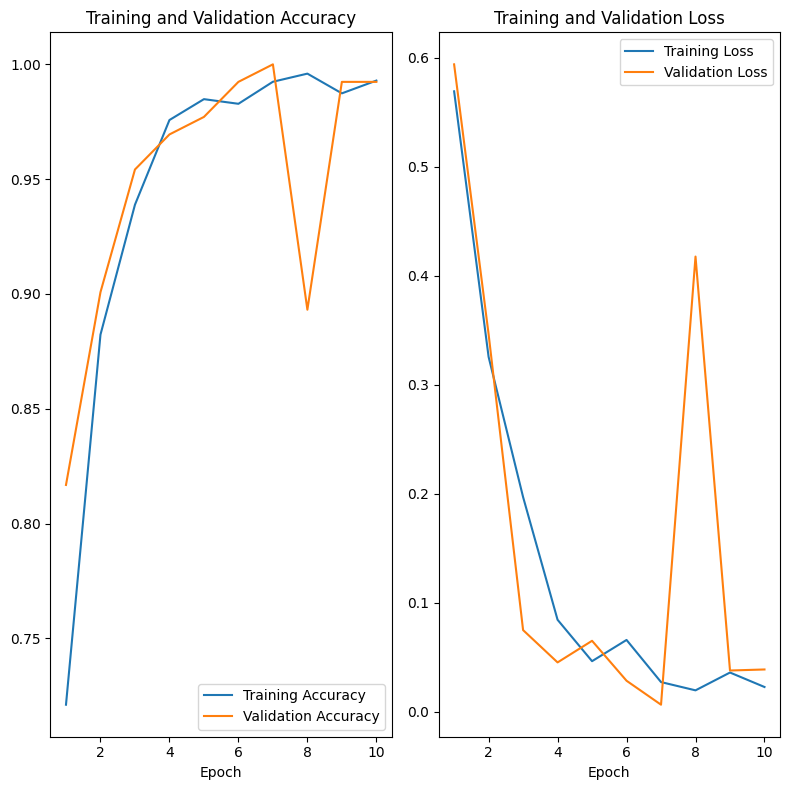

In [25]:
epochs_ran = min(len(acc), len(val_acc), len(loss), len(val_loss))
epoch_range = range(1, epochs_ran + 1)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epoch_range, acc[:epochs_ran], label="Training Accuracy")
plt.plot(epoch_range, val_acc[:epochs_ran], label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")

plt.subplot(1, 2, 2)
plt.plot(epoch_range, loss[:epochs_ran], label="Training Loss")
plt.plot(epoch_range, val_loss[:epochs_ran], label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()

First image to predict
Actual label: Pepper__bell___Bacterial_spot
Predicted label: Pepper__bell___Bacterial_spot


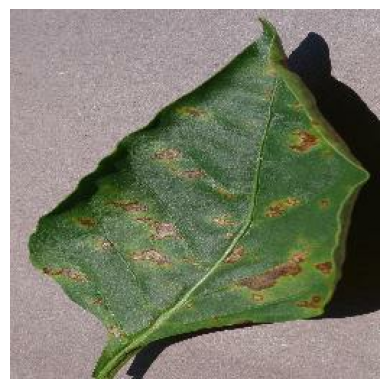

In [28]:
import numpy as np

for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0]
    first_label = int(labels_batch[0])

    print("First image to predict")
    plt.imshow(first_image)
    plt.axis("off")
    print("Actual label:", class_names[first_label])

    batch_prediction = model.predict(images_batch, verbose=0)
    print("Predicted label:", class_names[np.argmax(batch_prediction[0])])

In [29]:
def predict(model, img):
    img_array = tf.expand_dims(img, 0)
    predictions = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * float(np.max(predictions[0])), 2)
    return predicted_class, confidence

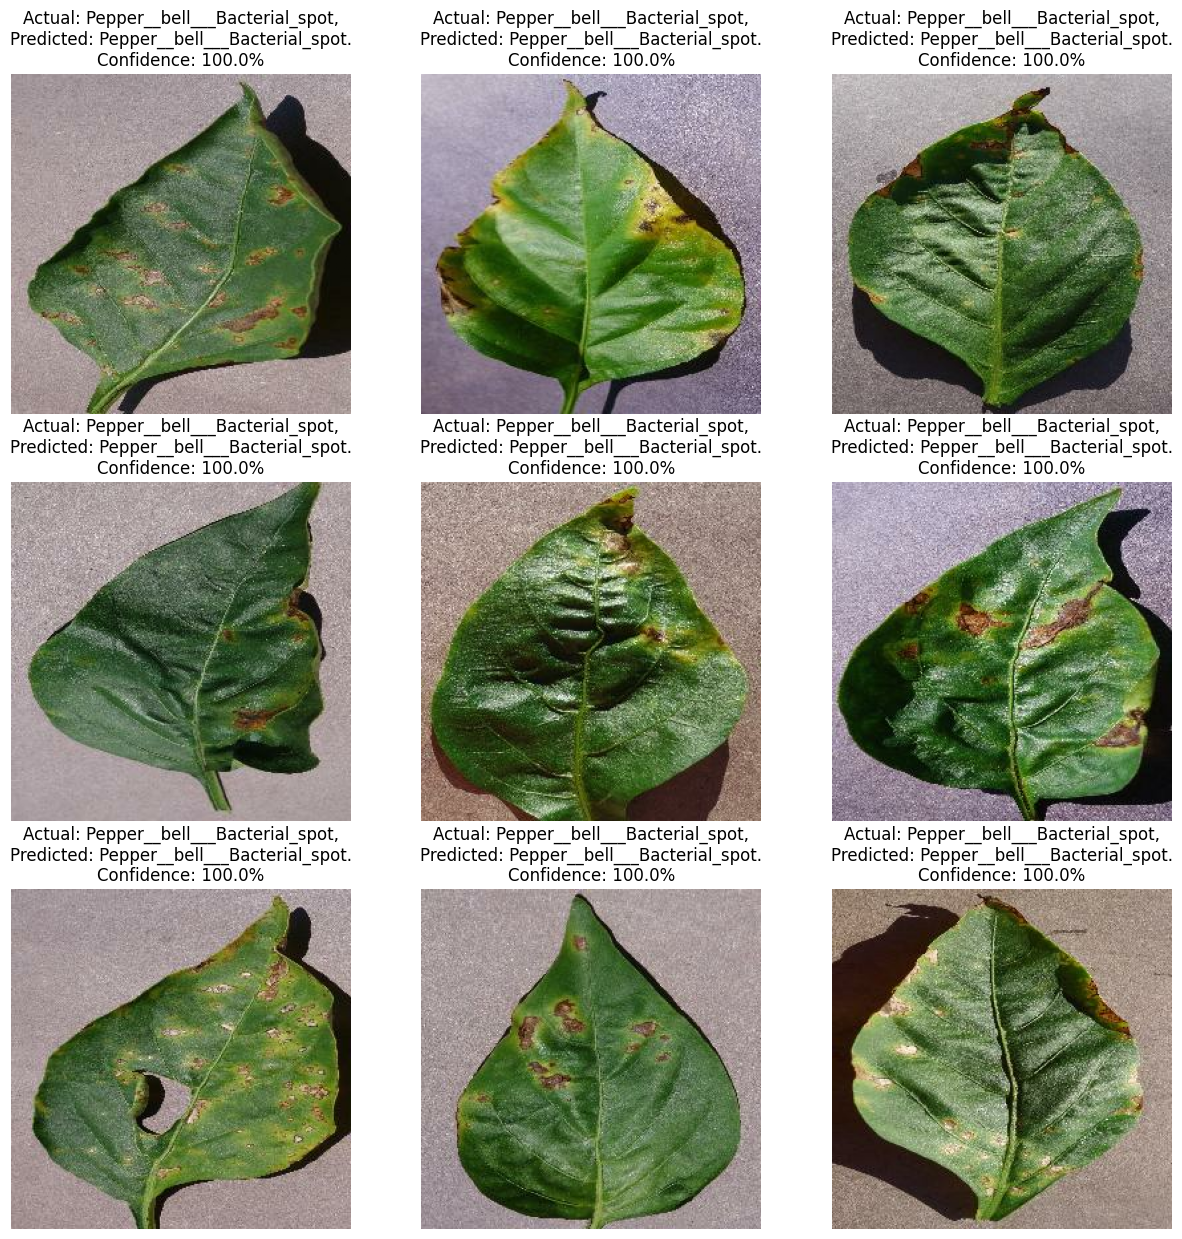

In [30]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])

        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[int(labels[i])]

        plt.title(f"Actual: {actual_class},\nPredicted: {predicted_class}.\nConfidence: {confidence}%")
        plt.axis("off")

In [31]:
model.save("./pepperBell.keras")